[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/Alternative_Role_Classifier_Analyzer.ipynb)

**📝 Before using:** Update the GitHub URL above with your actual username and repository name.

# =========================================================================
# 🚨 STEP 1: CHOOSE YOUR MODEL MODE
# =========================================================================

# Select one of the following modes:
#
# API-based (Requires API Key in Colab Secrets):
#   1. 'CLAUDE_API'            - Anthropic Claude Sonnet 4 / 4.5
#   2. 'GEMINI_API'            - Google Gemini 2.0 / 2.5
#   3. 'HUGGINGFACE_API'       - HuggingFace Inference API (multiple models available)
#
# Local/HuggingFace (Requires Colab GPU):
#   4. 'LLAMA_8B'              - Meta Llama 3.1 8B Instruct
#   5. 'LLAMA_70B'             - Meta Llama 3.1 70B Instruct (A100 recommended)
#   6. 'QWEN_7B'               - Qwen 2.5 7B Instruct
#   7. 'QWEN_80B'              - Qwen 3 Next 80B Instruct (A100 required)
#   8. 'DEEPSEEK_8B_QWEN'      - DeepSeek R1 Distill Qwen 8B
#   9. 'DEEPSEEK_8B_LLAMA'     - DeepSeek R1 Distill Llama 8B

MODEL_MODE = 'CLAUDE_API'  # <<< CHANGE THIS TO SWITCH MODELS >>>

# =========================================================================
# 🔑 STEP 2: API Keys & General Configuration
# =========================================================================

# API Keys (Set via Colab Secrets 🔑 or manually here)
ANTHROPIC_API_KEY = ""
GEMINI_API_KEY = ""
HF_TOKEN = ""  # HuggingFace API Token

# General Settings
ZIP_FILE_PATH = "/content/Evaluation Resources.zip"  # Expected location after upload
OUTPUT_PATH = "/content/analysis_results"
MAX_TOKENS = 2000
TEMPERATURE = 0.0  # Use 0.0 for deterministic, analytical reasoning
MAX_RETRIES = 3
RETRY_DELAY = 2.0

# CLAUDE Specific Settings (only used if MODEL_MODE = 'CLAUDE_API')
CLAUDE_MODEL_NAME = "claude-sonnet-4-20250514"  # Sonnet 4 is powerful and cost-effective
# CLAUDE_MODEL_NAME = "claude-opus-4-1-20250805" # Claude Opus 4.1
CLAUDE_FALLBACK_MODEL = "claude-sonnet-4-5-20250929"  # Fallback to Sonnet 4.5 if needed
ENABLE_PROMPT_CACHING = True  # Highly recommended for cost savings

# GEMINI Specific Settings (only used if MODEL_MODE = 'GEMINI_API')
GEMINI_MODEL_NAME = "gemini-2.5-pro" #"gemini-2.0-flash-exp"  # Fast and cost-effective

# HUGGINGFACE API Specific Settings (only used if MODEL_MODE = 'HUGGINGFACE_API')
# Choose one of the following models:
HUGGINGFACE_MODEL_NAME = "tiiuae/falcon-180B"  # Falcon-180B - Strong general purpose model
# HUGGINGFACE_MODEL_NAME = "Qwen/Qwen2.5-72B-Instruct"  # Qwen Max (closest available on HF)
# HUGGINGFACE_MODEL_NAME = "mistralai/Mixtral-8x22B-Instruct-v0.1"  # Mixtral-8x22B-Instruct
# Note: Qwen3-235B-A22B is not publicly available on HuggingFace API
# Note: BAAI/bge-m3 is an embedding model, not a chat model - see separate cell for embeddings

# LLAMA Specific Settings (only used if MODEL_MODE = 'LLAMA_8B' or 'LLAMA_70B')
LLAMA_8B_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
LLAMA_70B_MODEL_NAME = "meta-llama/Llama-3.1-70B-Instruct"
LLAMA_USE_4BIT = True  # Recommended to save VRAM

# QWEN Specific Settings (only used if MODEL_MODE = 'QWEN_7B' or 'QWEN_80B')
QWEN_7B_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
QWEN_80B_MODEL_NAME = "Qwen/Qwen3-Next-80B-A3B-Instruct"
QWEN_USE_4BIT = True  # Recommended to save VRAM

# DEEPSEEK Specific Settings (only used if MODEL_MODE starts with 'DEEPSEEK')
DEEPSEEK_QWEN_MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-8B"
DEEPSEEK_LLAMA_MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
DEEPSEEK_USE_4BIT = True  # Recommended to save VRAM

# =========================================================================
# 🔄 STEP 3: Dependency Installation (Runs automatically)
# =========================================================================

import os
import json
import zipfile
import time
from typing import Dict, List, Optional
import pandas as pd
from tqdm.auto import tqdm
from google.colab import files, userdata

print(f"\n{'='*70}")
print(f"Selected Model Mode: {MODEL_MODE}")
print(f"{'='*70}\n")

# Build installation command based on selected model
install_command = "pip install -q pandas numpy matplotlib seaborn plotly networkx tqdm"

if MODEL_MODE == 'CLAUDE_API':
    install_command += " anthropic>=0.34.0"
    try:
        ANTHROPIC_API_KEY = userdata.get('ANTHROPIC')
        print("✅ Anthropic API key loaded from Colab secrets.")
    except:
        print("⚠️ Warning: ANTHROPIC API key not found in secrets. Add it manually above.")

elif MODEL_MODE == 'GEMINI_API':
    install_command += " google-generativeai>=0.8.0"
    try:
        GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
        print("✅ Gemini API key loaded from Colab secrets.")
    except:
        print("⚠️ Warning: GEMINI_API_KEY not found in secrets. Add it manually above.")

elif MODEL_MODE == 'HUGGINGFACE_API':
    install_command += " huggingface-hub>=0.20.0"
    try:
        HF_TOKEN = userdata.get('HF_TOKEN')
        print("✅ HuggingFace API token loaded from Colab secrets.")
    except:
        print("⚠️ Warning: HF_TOKEN not found in secrets. Add it manually above.")

elif MODEL_MODE.startswith('LLAMA') or MODEL_MODE.startswith('QWEN') or MODEL_MODE.startswith('DEEPSEEK'):
    install_command += " transformers>=4.35.0 torch accelerate bitsandbytes"
    print("📦 Installing HuggingFace Transformers for local inference...")
else:
    raise ValueError(f"Unknown MODEL_MODE: {MODEL_MODE}")

print("\n📦 Installing dependencies...")
os.system(install_command)
print("✅ Dependencies installed.\n")

In [ ]:
# =========================================================================
# 🚨 STEP 1: CHOOSE YOUR MODEL MODE
# =========================================================================

# Select one of the following modes:
#
# API-based (Requires API Key in Colab Secrets):
#   1. 'CLAUDE_API'            - Anthropic Claude Sonnet 4 / 4.5
#   2. 'GEMINI_API'            - Google Gemini 2.0 / 2.5
#
# Local/HuggingFace (Requires Colab GPU):
#   3. 'LLAMA_8B'              - Meta Llama 3.1 8B Instruct
#   4. 'LLAMA_70B'             - Meta Llama 3.1 70B Instruct (A100 recommended)
#   5. 'QWEN_7B'               - Qwen 2.5 7B Instruct
#   6. 'QWEN_80B'              - Qwen 3 Next 80B Instruct (A100 required)
#   7. 'DEEPSEEK_8B_QWEN'      - DeepSeek R1 Distill Qwen 8B
#   8. 'DEEPSEEK_8B_LLAMA'     - DeepSeek R1 Distill Llama 8B

MODEL_MODE = 'CLAUDE_API'  # <<< CHANGE THIS TO SWITCH MODELS >>>

# =========================================================================
# 🔑 STEP 2: API Keys & General Configuration
# =========================================================================

# API Keys (Set via Colab Secrets 🔑 or manually here)
ANTHROPIC_API_KEY = ""
GEMINI_API_KEY = ""

# General Settings
ZIP_FILE_PATH = "/content/Evaluation Resources.zip"  # Expected location after upload
OUTPUT_PATH = "/content/analysis_results"
MAX_TOKENS = 2000
TEMPERATURE = 0.0  # Use 0.0 for deterministic, analytical reasoning
MAX_RETRIES = 3
RETRY_DELAY = 2.0

# CLAUDE Specific Settings (only used if MODEL_MODE = 'CLAUDE_API')
CLAUDE_MODEL_NAME = "claude-sonnet-4-20250514"  # Sonnet 4 is powerful and cost-effective
# CLAUDE_MODEL_NAME = "claude-opus-4-1-20250805" # Claude Opus 4.1
CLAUDE_FALLBACK_MODEL = "claude-sonnet-4-5-20250929"  # Fallback to Sonnet 4.5 if needed
ENABLE_PROMPT_CACHING = True  # Highly recommended for cost savings

# GEMINI Specific Settings (only used if MODEL_MODE = 'GEMINI_API')
GEMINI_MODEL_NAME = "gemini-2.5-pro" #"gemini-2.0-flash-exp"  # Fast and cost-effective

# LLAMA Specific Settings (only used if MODEL_MODE = 'LLAMA_8B' or 'LLAMA_70B')
LLAMA_8B_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
LLAMA_70B_MODEL_NAME = "meta-llama/Llama-3.1-70B-Instruct"
LLAMA_USE_4BIT = True  # Recommended to save VRAM

# QWEN Specific Settings (only used if MODEL_MODE = 'QWEN_7B' or 'QWEN_80B')
QWEN_7B_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
QWEN_80B_MODEL_NAME = "Qwen/Qwen3-Next-80B-A3B-Instruct"
QWEN_USE_4BIT = True  # Recommended to save VRAM

# DEEPSEEK Specific Settings (only used if MODEL_MODE starts with 'DEEPSEEK')
DEEPSEEK_QWEN_MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-8B"
DEEPSEEK_LLAMA_MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
DEEPSEEK_USE_4BIT = True  # Recommended to save VRAM

# =========================================================================
# 🔄 STEP 3: Dependency Installation (Runs automatically)
# =========================================================================

import os
import json
import zipfile
import time
from typing import Dict, List, Optional
import pandas as pd
from tqdm.auto import tqdm
from google.colab import files, userdata

print(f"\n{'='*70}")
print(f"Selected Model Mode: {MODEL_MODE}")
print(f"{'='*70}\n")

# Build installation command based on selected model
install_command = "pip install -q pandas numpy matplotlib seaborn plotly networkx tqdm"

if MODEL_MODE == 'CLAUDE_API':
    install_command += " anthropic>=0.34.0"
    try:
        ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
        print("✅ Anthropic API key loaded from Colab secrets.")
    except:
        print("⚠️ ANTHROPIC_API_KEY not found in secrets. Please set it manually above.")

elif MODEL_MODE == 'GEMINI_API':
    install_command += " google-genai"
    try:
        GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
        print("✅ Gemini API key loaded from Colab secrets.")
    except:
        print("⚠️ GEMINI_API_KEY not found in secrets. Please set it manually above.")

elif MODEL_MODE in ['LLAMA_8B', 'LLAMA_70B', 'QWEN_7B', 'QWEN_80B', 'DEEPSEEK_8B_QWEN', 'DEEPSEEK_8B_LLAMA']:
    install_command += " torch torchvision torchaudio transformers accelerate bitsandbytes"
    print("⚠️ Local model selected. Ensure you have GPU runtime enabled.")
    print("   Runtime → Change runtime type → Hardware accelerator: GPU")
    if MODEL_MODE in ['LLAMA_70B', 'QWEN_80B']:
        print("   ⚠️ Large model selected - A100 GPU strongly recommended.")

else:
    raise ValueError(f"Invalid MODEL_MODE: {MODEL_MODE}. Choose from: CLAUDE_API, GEMINI_API, LLAMA_8B, LLAMA_70B, QWEN_7B, QWEN_80B, DEEPSEEK_8B_QWEN, DEEPSEEK_8B_LLAMA")

print("\n📦 Installing dependencies...")
os.system(install_command)
print("✅ Dependencies installed.\n")


Selected Model Mode: CLAUDE_API

✅ Anthropic API key loaded from Colab secrets.

📦 Installing dependencies...
✅ Dependencies installed.



## 2. File Upload and Data Loading

In [ ]:
print("⬆️ Please upload 'Evaluation Resources.zip' when prompted.\n")
uploaded = files.upload()

if 'Evaluation Resources.zip' not in uploaded:
    raise FileNotFoundError("❌ 'Evaluation Resources.zip' not found. Please upload the file.")

# Extract zip file
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content/")
print("✅ Files extracted successfully.\n")

# =========================================================================
# 📂 LOAD DATA FILES
# =========================================================================

def find_and_load_json(filename: str) -> List[Dict]:
    """Search for and load a JSON file from extracted contents."""
    for root, dirs, files_list in os.walk("/content/"):
        for file in files_list:
            if file.lower() == filename.lower():
                filepath = os.path.join(root, file)
                with open(filepath, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                print(f"  ✅ Loaded {filename}: {len(data)} records")
                return data
    print(f"  ❌ Warning: {filename} not found")
    return []

print("🔍 Loading data files...\n")

# Load all required files
sample_jds = find_and_load_json('Sample_JDs.json')
classifications = find_and_load_json('Job_Classifications_Batch.json')
ground_truth = find_and_load_json('Ground_Truth_Masterfile.json')
ksacs = find_and_load_json('MNPS_KSACs.json')
problem_roles = find_and_load_json('Problem_Role_Cheatsheet.json')

# Store in dictionary for easy access
datasets = {
    'sample_jds': sample_jds,
    'classifications': classifications,
    'ground_truth': ground_truth,
    'ksacs': ksacs,
    'problem_roles': problem_roles
}

print(f"\n✅ Data loading complete!")

⬆️ Please upload 'Evaluation Resources.zip' when prompted.



Saving Evaluation Resources.zip to Evaluation Resources.zip
✅ Files extracted successfully.

🔍 Loading data files...

  ✅ Loaded Sample_JDs.json: 22 records
  ✅ Loaded Job_Classifications_Batch.json: 22 records
  ✅ Loaded Ground_Truth_Masterfile.json: 176 records
  ✅ Loaded MNPS_KSACs.json: 315 records
  ❌ Warning: Problem_Role_Cheatsheet.json not found

✅ Data loading complete!


## 3. Data Preparation

In [ ]:
# =========================================================================
# 🔗 MERGE JOB DESCRIPTIONS WITH CLASSIFICATIONS
# =========================================================================

def prepare_analysis_data(datasets: Dict) -> pd.DataFrame:
    """Merge job descriptions with classifications for analysis."""

    # Convert to DataFrames
    df_jds = pd.DataFrame(datasets['sample_jds'])
    df_class = pd.DataFrame(datasets['classifications'])

    # Standardize job titles for merging
    df_jds['Job Title'] = df_jds['Job Title'].astype(str).str.strip()
    df_class['job_title_original'] = df_class['job_title_original'].astype(str).str.strip()

    # Merge on job title (1:1 relationship)
    df_merged = pd.merge(
        df_class,
        df_jds,
        left_on='job_title_original',
        right_on='Job Title',
        how='inner'
    )

    # Create full job description text
    def create_jd_text(row):
        parts = []
        if 'Position Summary' in row and pd.notna(row['Position Summary']):
            parts.append(f"Position Summary: {row['Position Summary']}")
        if 'Essential Functions' in row and pd.notna(row['Essential Functions']):
            parts.append(f"Essential Functions: {row['Essential Functions']}")
        if 'Education' in row and pd.notna(row['Education']):
            parts.append(f"Education: {row['Education']}")
        if 'Work Experience' in row and pd.notna(row['Work Experience']):
            parts.append(f"Work Experience: {row['Work Experience']}")
        if 'Knowledge, Skills and Abilities' in row and pd.notna(row['Knowledge, Skills and Abilities']):
            parts.append(f"Knowledge, Skills and Abilities: {row['Knowledge, Skills and Abilities']}")
        return "\n\n".join(parts)

    df_merged['full_job_description'] = df_merged.apply(create_jd_text, axis=1)

    print(f"✅ Prepared {len(df_merged)} job records for analysis")

    if len(df_merged) != len(df_class):
        print(f"⚠️ Warning: {len(df_class) - len(df_merged)} records did not merge")

    return df_merged

# Prepare the analysis dataset
df_analysis = prepare_analysis_data(datasets)

# Display sample
print("\n📋 Sample records:")
display(df_analysis[['Job Code', 'job_title_original', 'major_role_group']].head())

✅ Prepared 22 job records for analysis

📋 Sample records:


,Job Code,job_title_original,major_role_group
0,87894,Teacher Grade 8,Teacher
1,86690,Mgr Data Quality and Integrity,Manager
2,85253,Coord Evaluation RAE,Analyst
3,84250,Dir Assessment RAE,Director
4,83552,Analyst Data Operations RAE,Analyst


## 4. Model Initialization

In [ ]:
# =========================================================================
# 🤖 MODEL INITIALIZATION
# =========================================================================

if MODEL_MODE == 'CLAUDE_API':
    import anthropic
    
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    model_name = CLAUDE_MODEL_NAME
    print(f"✅ Claude client initialized: {model_name}")
    
    def query_model(prompt: str) -> str:
        """Query Claude API with caching support"""
        messages = [{"role": "user", "content": prompt}]
        
        if ENABLE_PROMPT_CACHING and len(prompt) > 1024:
            # Use prompt caching for large prompts
            response = client.messages.create(
                model=model_name,
                max_tokens=MAX_TOKENS,
                temperature=TEMPERATURE,
                messages=messages,
                system=[
                    {
                        "type": "text",
                        "text": "You are an expert HR analyst specializing in job classification.",
                        "cache_control": {"type": "ephemeral"}
                    }
                ]
            )
        else:
            response = client.messages.create(
                model=model_name,
                max_tokens=MAX_TOKENS,
                temperature=TEMPERATURE,
                messages=messages
            )
        
        return response.content[0].text

elif MODEL_MODE == 'GEMINI_API':
    import google.generativeai as genai
    
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    model_name = GEMINI_MODEL_NAME
    print(f"✅ Gemini client initialized: {model_name}")
    
    def query_model(prompt: str) -> str:
        """Query Gemini API"""
        response = model.generate_content(
            prompt,
            generation_config=genai.types.GenerationConfig(
                temperature=TEMPERATURE,
                max_output_tokens=MAX_TOKENS,
            )
        )
        return response.text

elif MODEL_MODE == 'HUGGINGFACE_API':
    from huggingface_hub import InferenceClient
    
    client = InferenceClient(token=HF_TOKEN)
    model_name = HUGGINGFACE_MODEL_NAME
    print(f"✅ HuggingFace API client initialized: {model_name}")
    
    def query_model(prompt: str) -> str:
        """Query HuggingFace Inference API"""
        messages = [
            {"role": "system", "content": "You are an expert HR analyst specializing in job classification."},
            {"role": "user", "content": prompt}
        ]
        
        response = client.chat_completion(
            messages=messages,
            model=model_name,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE
        )
        
        return response.choices[0].message.content

elif MODEL_MODE in ['LLAMA_8B', 'LLAMA_70B']:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    
    model_name = LLAMA_8B_MODEL_NAME if MODEL_MODE == 'LLAMA_8B' else LLAMA_70B_MODEL_NAME
    print(f"📥 Loading Llama model: {model_name}")
    
    if LLAMA_USE_4BIT:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )
    else:
        quantization_config = None
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto",
        torch_dtype=torch.float16
    )
    print(f"✅ Llama model loaded: {model_name}")
    
    def query_model(prompt: str) -> str:
        """Query local Llama model"""
        messages = [
            {"role": "system", "content": "You are an expert HR analyst specializing in job classification."},
            {"role": "user", "content": prompt}
        ]
        
        input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
        
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_TOKENS,
            temperature=TEMPERATURE if TEMPERATURE > 0 else 0.1,
            do_sample=TEMPERATURE > 0,
            pad_token_id=tokenizer.eos_token_id
        )
        
        response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return response.strip()

elif MODEL_MODE in ['QWEN_7B', 'QWEN_80B']:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    
    model_name = QWEN_7B_MODEL_NAME if MODEL_MODE == 'QWEN_7B' else QWEN_80B_MODEL_NAME
    print(f"📥 Loading Qwen model: {model_name}")
    
    if QWEN_USE_4BIT:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )
    else:
        quantization_config = None
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto",
        torch_dtype=torch.float16,
        trust_remote_code=True
    )
    print(f"✅ Qwen model loaded: {model_name}")
    
    def query_model(prompt: str) -> str:
        """Query local Qwen model"""
        messages = [
            {"role": "system", "content": "You are an expert HR analyst specializing in job classification."},
            {"role": "user", "content": prompt}
        ]
        
        input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
        
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_TOKENS,
            temperature=TEMPERATURE if TEMPERATURE > 0 else 0.1,
            do_sample=TEMPERATURE > 0,
            pad_token_id=tokenizer.eos_token_id
        )
        
        response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return response.strip()

elif MODEL_MODE in ['DEEPSEEK_8B_QWEN', 'DEEPSEEK_8B_LLAMA']:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    
    model_name = DEEPSEEK_QWEN_MODEL_NAME if MODEL_MODE == 'DEEPSEEK_8B_QWEN' else DEEPSEEK_LLAMA_MODEL_NAME
    print(f"📥 Loading DeepSeek model: {model_name}")
    
    if DEEPSEEK_USE_4BIT:
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )
    else:
        quantization_config = None
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quantization_config,
        device_map="auto",
        torch_dtype=torch.float16,
        trust_remote_code=True
    )
    print(f"✅ DeepSeek model loaded: {model_name}")
    
    def query_model(prompt: str) -> str:
        """Query local DeepSeek model"""
        messages = [
            {"role": "system", "content": "You are an expert HR analyst specializing in job classification."},
            {"role": "user", "content": prompt}
        ]
        
        input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
        
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_TOKENS,
            temperature=TEMPERATURE if TEMPERATURE > 0 else 0.1,
            do_sample=TEMPERATURE > 0,
            pad_token_id=tokenizer.eos_token_id
        )
        
        response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return response.strip()

else:
    raise ValueError(f"Invalid MODEL_MODE: {MODEL_MODE}")

print(f"\n{'='*70}")
print(f"🎯 Model ready: {model_name}")
print(f"{'='*70}\n")


Initializing: CLAUDE_API

✅ Claude API client initialized (Model: claude-opus-4-1-20250805)
✅ Reference context builder ready


In [ ]:
# =========================================================================
# 🔢 OPTIONAL: BAAI BGE-M3 EMBEDDING MODEL
# =========================================================================
# This cell provides embedding functionality using BAAI/bge-m3
# Useful for semantic similarity analysis of job descriptions

def initialize_embedding_model():
    """Initialize the BAAI bge-m3 embedding model via HuggingFace API"""
    from huggingface_hub import InferenceClient
    
    try:
        hf_token = userdata.get('HF_TOKEN') if 'HF_TOKEN' not in globals() or not HF_TOKEN else HF_TOKEN
    except:
        hf_token = HF_TOKEN if HF_TOKEN else None
    
    if not hf_token:
        print("⚠️ HuggingFace API token not found. Please set HF_TOKEN in Colab secrets.")
        return None
    
    embedding_client = InferenceClient(token=hf_token)
    print("✅ BGE-M3 embedding model initialized")
    return embedding_client

def get_embeddings(texts: List[str], embedding_client) -> List[List[float]]:
    """Get embeddings for a list of texts using BAAI/bge-m3"""
    embeddings = []
    
    for text in tqdm(texts, desc="Generating embeddings"):
        try:
            # Get embedding from HuggingFace API
            embedding = embedding_client.feature_extraction(
                text=text,
                model="BAAI/bge-m3"
            )
            embeddings.append(embedding)
        except Exception as e:
            print(f"Error getting embedding: {e}")
            embeddings.append(None)
    
    return embeddings

def compute_similarity(embedding1: List[float], embedding2: List[float]) -> float:
    """Compute cosine similarity between two embeddings"""
    import numpy as np
    
    if embedding1 is None or embedding2 is None:
        return 0.0
    
    # Convert to numpy arrays
    vec1 = np.array(embedding1)
    vec2 = np.array(embedding2)
    
    # Compute cosine similarity
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    if norm1 == 0 or norm2 == 0:
        return 0.0
    
    return dot_product / (norm1 * norm2)

# Uncomment below to initialize embedding model
# embedding_client = initialize_embedding_model()

print("\n📊 Embedding functions defined. Use initialize_embedding_model() to activate.")
print("   Then use get_embeddings() and compute_similarity() for semantic analysis.\n")

## 5. Alternative Role Analyzer

In [ ]:
# =========================================================================
# 🔍 ALTERNATIVE ROLE ANALYZER - Complete Implementation
# =========================================================================

import time
import json
import pandas as pd
from tqdm.auto import tqdm
from typing import Dict, List, Optional

# -------------------------------------------------------------------------
# Configuration Constants
# -------------------------------------------------------------------------
MAX_RETRIES = 3
RETRY_DELAY = 2  # seconds
MAX_TOKENS = 2000
TEMPERATURE = 0.3

# =========================================================================
# AlternativeRoleAnalyzer Class
# =========================================================================

class AlternativeRoleAnalyzer:
    def __init__(self, df, datasets, model_mode, client, model_name_str, tokenizer=None, reference_ctx=None):
        self.df = df
        self.datasets = datasets
        self.model_mode = model_mode
        self.client = client
        self.model_name = model_name_str
        self.tokenizer = tokenizer
        self.reference_context = reference_ctx or ""

    def create_analysis_prompt(self, row: pd.Series) -> str:
        """Create prompt for alternative role identification."""

        job_code = row.get('Job Code', 'N/A')
        job_title = row.get('job_title_original', 'N/A')
        classified_role = row.get('major_role_group', 'N/A')
        job_description = row.get('full_job_description', 'N/A')

        # Get ground truth if available (Safe access)
        ground_truth = 'N/A'
        if self.datasets and 'ground_truth' in self.datasets:
            for gt_record in self.datasets['ground_truth']:
                if gt_record.get('Job Title', '').strip() == job_title.strip():
                    ground_truth = gt_record.get('major_role_group', 'N/A')
                    break

        prompt = f"""# ALTERNATIVE ROLE IDENTIFICATION TASK

You are an HR classification expert. Analyze the job description below and identify **other plausible major_role_group classifications** that could reasonably fit this position.

**Important**: This is NOT about determining if the classifier was correct or incorrect. Instead, identify alternative roles that would also make sense based on:
- KSAC (Knowledge, Skills, Abilities, Competencies) overlap
- Role scope and responsibilities
- Known ambiguity patterns between similar roles

## JOB INFORMATION

**Job Code:** {job_code}
**Job Title:** {job_title}
**Classified Role:** {classified_role}
**Ground Truth Role:** {ground_truth}

**Job Description:**
{job_description}

## REFERENCE CONTEXT

{self.reference_context}

## YOUR TASK

1. Review the job description carefully
2. Consider KSAC patterns and role similarities
3. Identify 1-5 alternative major_role_group values that could plausibly fit
4. Explain why each alternative is reasonable

## OUTPUT FORMAT

Return ONLY valid JSON with this structure:
```json
{{
  "job_code": "{job_code}",
  "classified_role": "{classified_role}",
  "other_plausible_roles": ["Role1", "Role2", "Role3"],
  "reasoning": "Brief explanation of why these alternatives are plausible based on KSAC overlap, role scope, or known ambiguity patterns."
}}
```

If no plausible alternatives exist, return an empty list for other_plausible_roles."""

        return prompt

    def generate_response(self, prompt: str) -> Dict:
        """Generate analysis using configured model."""

        for attempt in range(MAX_RETRIES):
            try:
                # ---------------------------------------------------------
                # CLAUDE API
                # ---------------------------------------------------------
                if self.model_mode == 'CLAUDE_API':
                    response = self.client.messages.create(
                        model=self.model_name,
                        max_tokens=MAX_TOKENS,
                        temperature=TEMPERATURE,
                        messages=[{"role": "user", "content": prompt}]
                    )
                    response_text = response.content[0].text

                # ---------------------------------------------------------
                # GEMINI API (V2)
                # ---------------------------------------------------------
                elif self.model_mode == 'GEMINI_API':
                    from google.genai import types

                    # Configure generation parameters (Native JSON mode)
                    config = types.GenerateContentConfig(
                        temperature=TEMPERATURE,
                        max_output_tokens=MAX_TOKENS,
                        response_mime_type="application/json"
                    )

                    response = self.client.models.generate_content(
                        model=self.model_name,
                        contents=prompt,
                        config=config
                    )

                    response_text = response.text

                # ---------------------------------------------------------
                # LOCAL MODELS (HuggingFace)
                # ---------------------------------------------------------
                else:
                    import torch
                    messages = [
                        {"role": "system", "content": "You are an HR classification expert."},
                        {"role": "user", "content": prompt}
                    ]

                    formatted_prompt = self.tokenizer.apply_chat_template(
                        messages, tokenize=False, add_generation_prompt=True
                    )

                    inputs = self.tokenizer(
                        formatted_prompt,
                        return_tensors="pt",
                        truncation=True,
                        max_length=4096
                    ).to(self.client.device)

                    with torch.no_grad():
                        outputs = self.client.generate(
                            **inputs,
                            max_new_tokens=MAX_TOKENS,
                            temperature=TEMPERATURE,
                            do_sample=TEMPERATURE > 0
                        )

                    # Slice output tokens instead of string splitting
                    input_length = inputs['input_ids'].shape[1]
                    generated_tokens = outputs[0][input_length:]
                    response_text = self.tokenizer.decode(generated_tokens, skip_special_tokens=True)

                # ---------------------------------------------------------
                # JSON Parsing & Cleanup
                # ---------------------------------------------------------
                response_text = response_text.strip()
                if response_text.startswith('```json'):
                    response_text = response_text[7:]
                if response_text.startswith('```'):
                    response_text = response_text[3:]
                if response_text.endswith('```'):
                    response_text = response_text[:-3]

                result = json.loads(response_text.strip())
                result['status'] = 'success'
                return result

            except Exception as e:
                if attempt < MAX_RETRIES - 1:
                    wait_time = RETRY_DELAY * (2 ** attempt)
                    print(f"\r⚠️ Retry {attempt + 1}/{MAX_RETRIES} after {wait_time:.0f}s... (Error: {str(e)[:50]})", end="")
                    time.sleep(wait_time)
                else:
                    return {
                        'job_code': 'N/A',
                        'classified_role': 'N/A',
                        'other_plausible_roles': [],
                        'reasoning': f'Analysis failed: {str(e)[:200]}',
                        'status': 'failed'
                    }

    def analyze_all(self) -> pd.DataFrame:
        """Analyze all job records."""
        results = []

        print(f"\n🚀 Starting analysis with {self.model_mode} ({self.model_name})...\n")

        for idx, row in tqdm(self.df.iterrows(), total=len(self.df), desc="Analyzing jobs"):
            prompt = self.create_analysis_prompt(row)
            result = self.generate_response(prompt)

            results.append({
                'Job Code': row.get('Job Code', 'N/A'),
                'Classified Role': row.get('major_role_group', 'N/A'),
                'Other Plausible Roles': ', '.join(result.get('other_plausible_roles', [])),
                'Analysis Reasoning': result.get('reasoning', 'N/A'),
                'Status': result.get('status', 'failed')
            })

        return pd.DataFrame(results)

# =========================================================================
# Initialize Analyzer (if data is loaded)
# =========================================================================

if 'df_analysis' in globals() and 'datasets' in globals():
    analyzer = AlternativeRoleAnalyzer(
        df=df_analysis,
        datasets=datasets,
        model_mode=MODEL_MODE,
        client=model_client,
        model_name_str=model_name,
        tokenizer=model_tokenizer,
        reference_ctx=reference_context
    )
    print("✅ AlternativeRoleAnalyzer initialized and ready!")
    print(f"📊 Loaded {len(df_analysis)} records for analysis")
else:
    print("📦 AlternativeRoleAnalyzer class defined successfully!")
    print("⚠️  Waiting for data to be loaded...")
    print("   Run your data loading step to define 'df_analysis' and 'datasets'")

✅ AlternativeRoleAnalyzer initialized and ready!
📊 Loaded 22 records for analysis


## 6. Run Analysis

In [ ]:
# =========================================================================
# ▶️ EXECUTE ANALYSIS
# =========================================================================

df_results = analyzer.analyze_all()

# Calculate statistics
success_rate = (df_results['Status'] == 'success').mean()
jobs_with_alternatives = (df_results['Other Plausible Roles'].str.len() > 0).sum()
total_jobs = len(df_results)

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)
print(f"Total Jobs Analyzed: {total_jobs}")
print(f"Successful Analyses: {(df_results['Status'] == 'success').sum()} ({success_rate:.1%})")
print(f"Jobs with Alternatives: {jobs_with_alternatives} ({jobs_with_alternatives/total_jobs:.1%})")
print("="*70 + "\n")

# Display results
print("📋 Sample Results:\n")
display(df_results.drop(columns=['Status']).head(10))


🚀 Starting analysis with CLAUDE_API (claude-opus-4-1-20250805)...



Analyzing jobs:   0%|          | 0/22 [00:00<?, ?it/s]

⚠️ Retry 2/3 after 4s... (Error: Error code: 400 - {'type': 'error', 'error': {'typ)
✅ ANALYSIS COMPLETE
Total Jobs Analyzed: 22
Successful Analyses: 19 (86.4%)
Jobs with Alternatives: 19 (86.4%)

📋 Sample Results:



,Job Code,Classified Role,Other Plausible Roles,Analysis Reasoning
0,87894,Teacher,"Advisor, Aide",Advisor shares significant KSAC overlap with t...
1,86690,Manager,"Analyst, Advisor",Analyst is plausible due to strong overlap in ...
2,85253,Analyst,Advisor,The Advisor role is plausible because this pos...
3,84250,Director,"Analyst, Advisor",Analyst is plausible due to heavy emphasis on ...
4,83552,Analyst,"Associate, Administrative Assistant",Associate is plausible due to overlapping KSAC...
5,85491,Coordinator,"Advisor, Manager, Specialist",Advisor is plausible due to the role's emphasi...
6,88129,Teacher,"Advisor, Aide",Advisor could fit due to the counseling/guidan...
7,85789,Coach,"Advisor, Analyst, Associate","Advisor fits due to the role's consultation, t..."
8,82509,Coach,"Advisor, Analyst, Architect (Technology-Focused)",Advisor fits due to subject matter expertise i...
9,83222,Coordinator,"Advisor, Analyst, Manager",Advisor is plausible because this role provide...


## 7. Visualizations

📊 Generating visualizations...



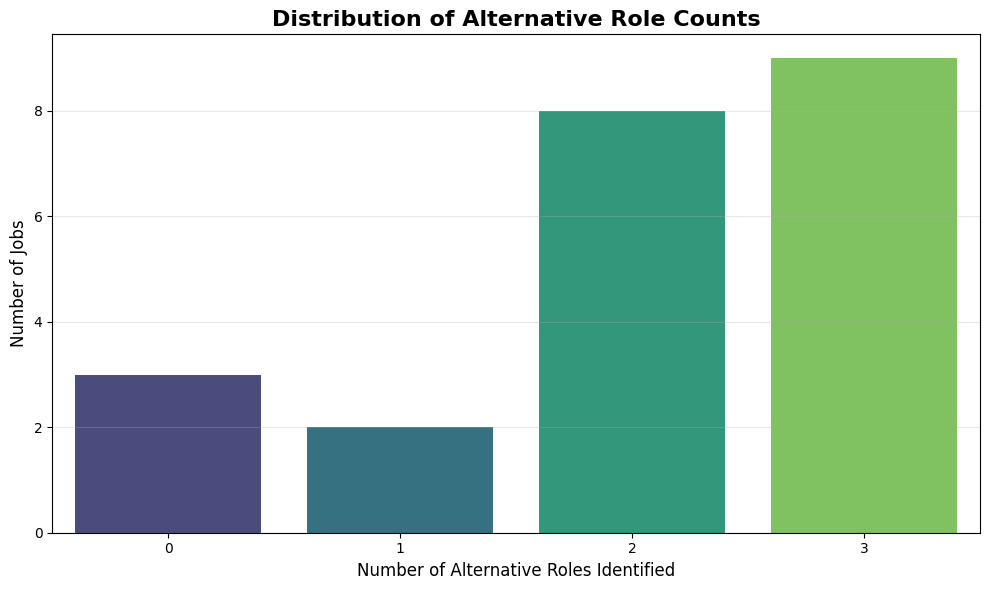

  ✅ Alternative distribution chart saved


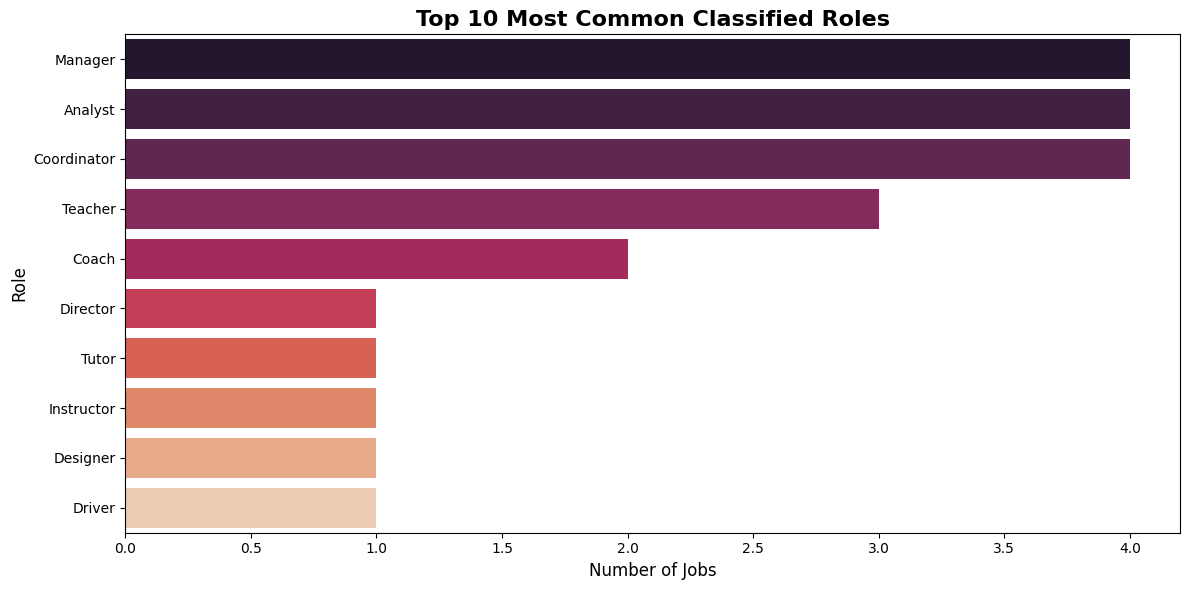

  ✅ Top roles chart saved


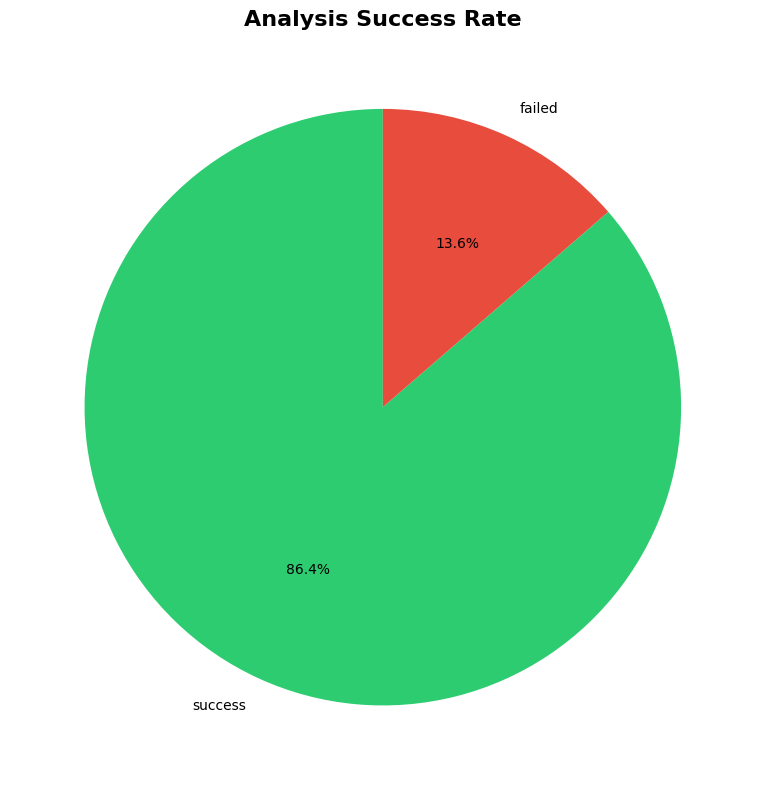

  ✅ Status breakdown chart saved



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("📊 Generating visualizations...\n")

# =========================================================================
# 1. Distribution of Alternative Counts
# =========================================================================

df_results['alt_count'] = df_results['Other Plausible Roles'].apply(
    lambda x: len([r.strip() for r in str(x).split(',') if r.strip()])
)

plt.figure(figsize=(10, 6))
sns.countplot(data=df_results, x='alt_count', palette='viridis')
plt.title('Distribution of Alternative Role Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Alternative Roles Identified', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(range(0, df_results['alt_count'].max() + 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/alternative_distribution.png", dpi=300)
plt.show()

print("  ✅ Alternative distribution chart saved")

# =========================================================================
# 2. Top Classified Roles
# =========================================================================

plt.figure(figsize=(12, 6))
top_roles = df_results['Classified Role'].value_counts().head(10)
sns.barplot(x=top_roles.values, y=top_roles.index, palette='rocket')
plt.title('Top 10 Most Common Classified Roles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/top_roles.png", dpi=300)
plt.show()

print("  ✅ Top roles chart saved")

# =========================================================================
# 3. Analysis Status
# =========================================================================

plt.figure(figsize=(8, 8))
status_counts = df_results['Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors[:len(status_counts)], startangle=90)
plt.title('Analysis Success Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/status_breakdown.png", dpi=300)
plt.show()

print("  ✅ Status breakdown chart saved\n")

## 8. Export Results

In [ ]:
import shutil

# =========================================================================
# 💾 EXPORT RESULTS
# =========================================================================

# Save main results CSV
output_csv = f"{OUTPUT_PATH}/alternative_roles_analysis_{MODEL_MODE.lower()}.csv"
df_results.drop(columns=['Status', 'alt_count']).to_csv(output_csv, index=False)
print(f"✅ Results saved to: {output_csv}\n")

# Save summary statistics
summary = {
    'model_used': MODEL_MODE,
    'model_name': model_name,
    'total_jobs': total_jobs,
    'successful_analyses': int((df_results['Status'] == 'success').sum()),
    'success_rate': f"{success_rate:.1%}",
    'jobs_with_alternatives': int(jobs_with_alternatives),
    'percentage_with_alternatives': f"{jobs_with_alternatives/total_jobs:.1%}",
    'avg_alternatives_per_job': float(df_results['alt_count'].mean())
}

with open(f"{OUTPUT_PATH}/analysis_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print("📊 Analysis Summary:")
print(json.dumps(summary, indent=2))
print()

# Create downloadable zip
print("📦 Creating download package...")
shutil.make_archive('/content/analysis_results', 'zip', OUTPUT_PATH)

try:
    files.download('/content/analysis_results.zip')
    print("✅ Download initiated!\n")
except:
    print(f"⚠️ Could not auto-download. Files saved to: {OUTPUT_PATH}\n")

print("="*70)
print("🎉 ANALYSIS PIPELINE COMPLETE!")
print("="*70)

✅ Results saved to: /content/analysis_results/alternative_roles_analysis_claude_api.csv

📊 Analysis Summary:
{
  "model_used": "CLAUDE_API",
  "model_name": "claude-opus-4-1-20250805",
  "total_jobs": 22,
  "successful_analyses": 19,
  "success_rate": "86.4%",
  "jobs_with_alternatives": 19,
  "percentage_with_alternatives": "86.4%",
  "avg_alternatives_per_job": 2.0454545454545454
}

📦 Creating download package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated!

🎉 ANALYSIS PIPELINE COMPLETE!


## 9. Model Selection Guide

### Quick Reference

| Model | Type | Speed | Cost | Memory | Best For |
|:------|:-----|:------|:-----|:-------|:---------|
| **Claude Sonnet 4** | API | ⚡⚡⚡ | 💰💰 | N/A | Production, accuracy |
| **Gemini 2.0 Flash** | API | ⚡⚡⚡ | 💰 | N/A | Fast, cost-effective |
| **Falcon-180B** | HF API | ⚡⚡ | 💰 | N/A | Powerful general model |
| **Mixtral-8x22B** | HF API | ⚡⚡ | 💰 | N/A | Strong reasoning |
| **Qwen 2.5 72B** | HF API | ⚡⚡ | 💰 | N/A | Excellent for analysis |
| **Llama 3.1 8B** | Local | ⚡⚡ | Free | ~6GB | Quick testing |
| **Llama 3.1 70B** | Local | ⚡ | Free | ~35GB | High accuracy |
| **Qwen 2.5 7B** | Local | ⚡⚡ | Free | ~5GB | Efficient |
| **Qwen 3 80B** | Local | ⚡ | Free | ~40GB | Best local model |
| **DeepSeek-R1 8B** | Local | ⚡⚡ | Free | ~6GB | Reasoning tasks |

### API Models (Recommended)

#### Anthropic Claude
**Setup:**
1. Get API key: https://console.anthropic.com/
2. Add to Colab Secrets (🔑 icon in left sidebar) as `ANTHROPIC_API_KEY`
3. Set `MODEL_MODE = 'CLAUDE_API'` in Cell 1

**Pros:** Excellent accuracy, fast, prompt caching saves costs  
**Cons:** Moderate cost per request

#### Google Gemini
**Setup:**
1. Get API key: https://aistudio.google.com/
2. Add to Colab Secrets as `GEMINI_API_KEY`
3. Set `MODEL_MODE = 'GEMINI_API'` in Cell 1

**Pros:** Very fast, low cost, good accuracy  
**Cons:** Less sophisticated than Claude for complex reasoning

#### HuggingFace API (NEW!)
**Setup:**
1. Get API key: https://huggingface.co/settings/tokens
2. Add to Colab Secrets as `HUGGINGFACE_API_KEY`
3. Set `MODEL_MODE = 'HUGGINGFACE_API'` in Cell 1
4. Choose model in `HUGGINGFACE_MODEL_NAME`:
   - `"tiiuae/falcon-180B"` - Falcon-180B (powerful, general purpose)
   - `"mistralai/Mixtral-8x22B-Instruct-v0.1"` - Mixtral-8x22B (strong reasoning)
   - `"Qwen/Qwen2.5-72B-Instruct"` - Qwen 2.5 72B (excellent for analysis)

**Available HuggingFace Models:**
- **Falcon-180B**: Large, powerful model with strong general capabilities
- **Mixtral-8x22B-Instruct**: Mixture-of-experts architecture, excellent reasoning
- **Qwen 2.5 72B**: Best available Qwen model on HF API (Note: Qwen3-235B not yet available)

**Note on Requested Models:**
- ✅ **Falcon-180B**: Available and configured
- ⚠️ **Qwen3-235B-A22B (Qwen-Max)**: Not publicly available on HuggingFace API. Using Qwen 2.5 72B as alternative
- ✅ **Mixtral-8x22B-Instruct**: Available and configured
- ℹ️ **BAAI bge-m3**: Embedding model (not for chat) - see separate cell for usage

**Pros:** Multiple model options, competitive pricing, no rate limits  
**Cons:** May be slower than Claude/Gemini for some models

### Embedding Model: BAAI BGE-M3
**Purpose:** Generate semantic embeddings for similarity analysis

**Setup:**
1. Same HuggingFace API key as above
2. Run the embedding cell after model initialization
3. Use `initialize_embedding_model()` to activate

**Functions:**
- `get_embeddings(texts)` - Generate embeddings for text list
- `compute_similarity(emb1, emb2)` - Calculate cosine similarity

**Use Cases:**
- Compare job description similarities
- Find semantically related roles
- Cluster similar positions
- Validate classification boundaries

### Local Models

**Setup:**
1. Enable GPU: Runtime → Change runtime type → GPU
2. Choose model size based on available VRAM
3. Set `MODEL_MODE` to desired model in Cell 1

**Pros:** Free, unlimited requests, private  
**Cons:** Slower, requires GPU, memory constraints

### Recommendations

- **For production analysis:** Claude Sonnet 4 (best accuracy, caching reduces cost)
- **For budget-conscious work:** Gemini 2.0 Flash (fast + cheap)
- **For testing HF models:** Mixtral-8x22B or Qwen 2.5 72B (good balance)
- **For maximum power:** Falcon-180B via HF API
- **For free/private work:** Qwen 2.5 7B or Llama 3.1 8B (local)
- **For best free results:** Qwen 3 80B or Llama 3.1 70B (requires A100 GPU)
- **For semantic analysis:** BAAI bge-m3 embeddings (separate from chat models)

### Troubleshooting

**Out of Memory (Local Models):**
- Use smaller model (8B instead of 70B)
- Ensure 4-bit quantization is enabled
- Request A100 GPU runtime

**API Errors:**
- Check API key in Colab Secrets
- Verify account has credits/access
- Check rate limits (HF API has generous limits)
- For HF: Ensure model is available (some require special access)

**Slow Performance:**
- API models: Already optimized
- Local models: Use smaller model or switch to API
- HF API: Try different model (Mixtral often faster than Falcon)

**Model Not Available:**
- Some HF models require authentication or special access
- Check model card on HuggingFace for requirements
- Try alternative model from the same family